<a href="https://colab.research.google.com/github/MarcoMilla/MarcoMilla.github.io/blob/master/03MIAR_MarcosMilla_AG2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03MIAR - Algoritmos de optimización
## Actividad guiada 2

## Alumno: **Marcos Antonio Milla Tranca**

https://colab.research.google.com/drive/1fBPWHi45Lai2udnhfqTL69hDucKu81vf

https://github.com/MarcoMilla/MarcoMilla.github.io/blob/master/03MIAR_MarcosMilla_AG2.ipynb

## Objetivos
- Comprender la utilidad y aplicar algoritmos dinámicos
- Comprender la utilidad y aplicar algoritmos de ramificación y poda
- Comprender la utilidad y aplicar el algoritmo de optimización por descenso de gradiente



### **Programación dinámica - Problema del viaje por el río**
- Se divide el problema en subproblemas más pequeños para poder usar las soluciones más adelante
- Si el problema verifica el principio de optimalidad de Bellman "en una secuencia óptima de decisiones, toda sub-secuencia es también óptima" esto funciona bien
- Guardar soluciones parciales + recursividad = complejidad

#### **Problema**<br>
En un río hay **n** embarcaderos y debemos desplazarnos río abajo desde un embarcadero a otro. Cada embarcadero tiene precios diferentes para ir de un embarcadero a otro situado más abajo. Para ir del embarcadero i al j, puede ocurrir que sea más barato hacer un trasbordo por un embarcadero intermedio k. El problema consiste en determinar la combinación más barata.

In [1]:
import math

i = float("inf")

tarifas = [
    [0, 5, 4, 3, i, i, i],
    [i, 0, i, 2, 3, i, 11],
    [i, i, 0, 1, i, 4, 10],
    [i, i, i, 0, 5, 6, 9],
    [i, i, i, i, 0, i ,4],
    [i, i, i, i, i, 0, 3],
    [i, i, i, i, i, i, 0]
]

# Función para obtener precios finales entre dos nodos y qué rutas seguir
def obtener_precios_y_rutas(tarifas):
    # Inicialización de tabla de precios y rutas (precios a infinito como peor caso)
    nodos = len(tarifas[0])
    precios = [[i]*nodos for i in [float("inf")]*nodos]
    ruta = [[i]*nodos for i in [""]*nodos]

    # Recorremos todos los caminos (desde "n" hasta un "n" superior -> Ej: 0 a 1, 0 a 2, 1 a 4... pero nunca de 1 a 0 o de 4 a 2)
    for i in range(nodos-1):
        for j in range(i+1,nodos):

            # Asumimos que el mínimo es la tarifa de un nodo a otro inicialmente
            minimo = tarifas[i][j]
            # Asumimos que la mejor ruta de un nodo a otro comienza en el nodo inicial (ej: 0,1 -> 0, 0,4 -> 0, 2,5 -> 2)
            ruta[i][j] = i

            # Recorremos posibles movimientos intermedios
            for k in range(i,j):
                #print(precios)
                #print(f"i: {i}, j: {j}, k: {k}, precios_ik: {precios[i][k]}, tarifas_kj: {tarifas[k][j]}")
                # Si el precio de ir de i a k más la tarifa de k a j es menor que la tarifa de i a j, nos quedamos con esa ruta
                if (precios[i][k] + tarifas[k][j] < minimo):
                    minimo = precios[i][k] + tarifas[k][j]
                    ruta[i][j] = k
                # Actualizamos precio de i a j como el mínimo (puede ser pasando por k)
                precios[i][j] = minimo

    # Retornamos tabla de precios y de rutas de un nodo a otro
    return precios, ruta

# Función que calcula la ruta óptima a seguir
def calcular_ruta(ruta, inicio, fin, resultado = []):
    # Si el nodo inicial es igual al final, devolvemos el nodo
    if inicio == fin:
        #print(f"{inicio}")
        resultado.append(inicio)
        return resultado
    # Si tengo que desplazarme, calculo recursivamente la ruta de inicio a final siguiendo la tabla de rutas
    else:
        #print(f"{fin}")
        resultado.append(fin)
        return calcular_ruta(ruta, inicio, ruta[inicio][fin])

precios, ruta = obtener_precios_y_rutas(tarifas)

for fila in precios:
  print(fila)
print("---")
for fila in ruta:
  print(fila)

desde=0
hasta=6
resultado = calcular_ruta(ruta, desde, hasta)
print("---")
print(f"La ruta a seguir es: {resultado[::-1]}")

[inf, 5, 4, 3, 8, 8, 11]
[inf, inf, inf, 2, 3, 8, 7]
[inf, inf, inf, 1, 6, 4, 7]
[inf, inf, inf, inf, 5, 6, 9]
[inf, inf, inf, inf, inf, inf, 4]
[inf, inf, inf, inf, inf, inf, 3]
[inf, inf, inf, inf, inf, inf, inf]
---
['', 0, 0, 0, 1, 2, 5]
['', '', 1, 1, 1, 3, 4]
['', '', '', 2, 3, 2, 5]
['', '', '', '', 3, 3, 3]
['', '', '', '', '', 4, 4]
['', '', '', '', '', '', 5]
['', '', '', '', '', '', '']
---
La ruta a seguir es: [0, 2, 5, 6]


### **Ramificación y poda - Problema de las tareas**
- Se necesitan funciones auxiliares para calcular todo el grafo (árbol)
- Función para calcular costes de soluciones parciales (no completas)
- Función para calcular cota inferior (muy optimista, repitiendo tareas si es necesario aunque la poda sea peor)
- Función para crear hijos e ir construyendo las soluciones
- Función para ramificar nodos y podar

In [2]:
import itertools
import math

costes = [
    [11,12,18,40],
    [14,15,13,22],
    [11,17,19,23],
    [17,14,20,28]
]

#for s in itertools.permutations(range(len(costes))):
#  print(s)

In [3]:
def fuerza_bruta(costes):

    optimo = float("inf")

    for s in itertools.permutations(range(len(costes))):
        coste = sum(costes[i][s[i]] for i in range(len(costes))) # Acumulo costes de cada agente
        if (coste < optimo):
            tareas, optimo = s, coste

    return tareas, optimo

tareas, optimo = fuerza_bruta(costes)
print(f"Obtenida mejor solución {tareas} con coste {optimo} por fuerza bruta")

Obtenida mejor solución (0, 2, 3, 1) con coste 61 por fuerza bruta


In [4]:
def coste_parcial(solucion, costes):
    coste = 0

    for i in range(len(solucion)):
        coste += costes[i][solucion[i]]

    return coste

coste = coste_parcial((0,1),costes) # 11 + 15 = 26
print(coste)

26


In [5]:
def cota_inferior(solucion, costes):
    # Calculo el coste parcial de la solución dada
    coste = coste_parcial(solucion,costes)

    # Calculo coste mínimo de opciones restantes no usadas permitiendo reutilización por sencillez (relajación = menos poda)
    no_usadas = set(range(len(costes)))-set(solucion)

    for i in range(len(solucion),len(costes)):
        coste += min([costes[i][j] for j in no_usadas])

    return coste

CI = cota_inferior((0,1),costes)
print(CI)

65


In [6]:
def cota_superior(solucion, costes):
     # Calculo el coste parcial de la solución dada
     coste = coste_parcial(solucion,costes)

     # Calculo coste máximo de opciones restantes no usadas
     no_usadas = set(range(len(costes)))-set(solucion)

     for i in range(len(solucion),len(costes)):
         coste += max([costes[i][j] for j in no_usadas])

     return coste

 #CS = cota_superior((0,1),costes)
 #print(CS)

In [7]:
# Función para crear las ramas del árbol
def crear_hijos(solucion, dimension):
  hijos = []
  for i in range(dimension):
    if i not in solucion:
      hijos.append({'s':solucion + (i,)})
  return hijos

crear_hijos((0,1),4)

[{'s': (0, 1, 2)}, {'s': (0, 1, 3)}]

In [8]:
def ramificacion_y_poda(costes):

    dimension = len(costes)

    # Inicializo solución a vacío con el peor coste posible
    mejor_solucion = tuple(i for i in range(dimension))
    mejor_coste = coste_parcial(mejor_solucion,costes)

    # Creo un array de nodos y lo inicializo con una solución vacía (para comenzar por algo)
    nodos = []
    nodos.append({'s':(), 'ci':cota_inferior((),costes)})

    # Llevo cuenta de iteraciones por debugging
    iteracion = 0

    # Mientras haya nodos por explorar, aplico ramificación y poda
    while(nodos):
        # Cojo el nodo más prometedor (menor cota inferior, aunque esto luego puede ser "peor" a posteriori)
        nodo = min(nodos, key=lambda x: x['ci'])

        # Ramifico el nodo para obtener sus hijos
        hijos = crear_hijos(nodo['s'],dimension)

        # Para cada hijo, hago el procesamiento adecuado antes de decidir si es solución completa o un nuevo nodo
        for hijo in hijos:

            # Si la dimensión de la solución es igual a la dimensión de costes, es una solución final
            if (len(hijo['s']) == dimension):
                # Calculo el coste de la solución obtenida en el árbol
                coste = coste_parcial(hijo['s'],costes)
                # Si el coste es mejor, me lo quedo como solución
                if (coste < mejor_coste):
                    mejor_solucion = hijo['s']
                    mejor_coste = coste

            # Si la dimensión de la solución no es igual a la dimensión de costes, aplico poda
            else:
                # Calculo cota inferior del hijo
                cota_inferior_hijo = cota_inferior(hijo['s'], costes)
                # Si la cota inferior es menor que el mejor coste, lo añado a la lista de nodos a actualizar
                # Si la cota inferior fuera mayor, no tiene sentido porque no puede mejorar mi solución -> Poda
                if (cota_inferior_hijo <= mejor_coste):
                    nodos.append({'s':hijo['s'], 'ci':cota_inferior_hijo})
                #else:
                    #print(mejor_coste)
                    #print(f"Nodo eliminado: {hijo['s']} con cota inferior {cota_inferior_hijo}")

        # Elimino el nodo ya mirado
        nodos.remove(nodo)

        # Llevo la cuenta de las iteraciones que hago
        iteracion += 1

    return iteracion, mejor_solucion, mejor_coste

iteraciones, mejor_solucion, mejor_coste = ramificacion_y_poda(costes)
print(f"Obtenida mejor solución {mejor_solucion} con coste {mejor_coste} en {iteraciones} iteraciones")

Obtenida mejor solución (0, 2, 3, 1) con coste 61 en 17 iteraciones


### **Descenso del gradiente - Optimización de funciones**
- Se lleva a cabo una optimización basada en el método del descenso de gradiente
- Se calcula el vector de derivadas parciales y se minimiza la función objetivo actualizando los nuevos puntos (ver figura)

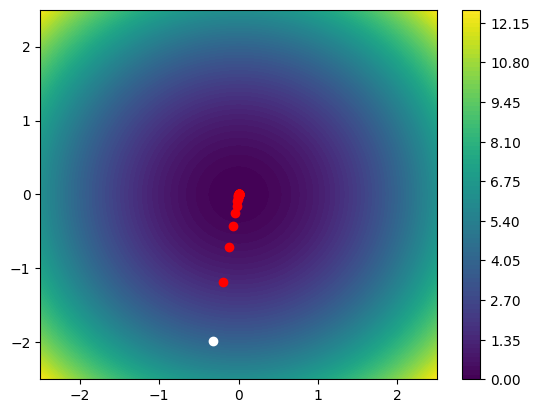

In [9]:
import math
import matplotlib.pyplot as plt
import numpy as np
import random

f = lambda X : X[0]**2 + X[1]**2 # x^2 + y^2
df = lambda X : [2*X[0] , 2*X[1]] # (2x, 2y)

resolucion = 100
rango = 2.5
X = np.linspace(-rango, rango, resolucion)
Y = np.linspace(-rango, rango, resolucion)
Z = np.zeros([resolucion, resolucion])

for ix, x in enumerate(X):
    for iy, y in enumerate(Y):
        Z[ix,iy] = f([x,y])

plt.contourf(X, Y, Z, resolucion)
plt.colorbar()

P = [random.uniform(-2,2), random.uniform(-2,2)]
plt.plot(P[0],P[1],"o",c="white")

tasa_aprendizaje = 0.2
for _ in range(500):
    grad = df(P)
    P[0], P[1] = P[0] - tasa_aprendizaje*grad[0], P[1] - tasa_aprendizaje*grad[1]
    plt.plot(P[0],P[1],"o",c="red")

## **Actividades extra**




### **1. Ramificación y poda**
  - Generar matrices con valores aleatorios de mayores dimensiones (5,6,7,…) y ejecutar ambos algoritmos.
  - ¿A partir de que dimensión el algoritmo por fuerza bruta deja de ser una opción?
  - ¿Hay algún valor de la dimensión a partir de la cual el algoritmo de ramificación y poda también deja de ser una opción válida?

In [10]:
import numpy as np
import itertools
import time
import heapq

def generar_matriz(n):
    #Genera una matriz cuadrada NxN con costos aleatorios entre 1 y 100
    return np.random.randint(1, 100, size=(n, n))

def algoritmo_fuerza_bruta(matriz):
    #Evalúa todas las permutaciones posibles (N!).
    n = matriz.shape[0]
    min_costo = float('inf')

    # Genera todas las combinaciones posibles de asignación
    for permutacion in itertools.permutations(range(n)):
        # Calcula el costo de la permutación actual
        costo_actual = sum(matriz[i][permutacion[i]] for i in range(n))
        if costo_actual < min_costo:
            min_costo = costo_actual

    return min_costo

def algoritmo_ramificacion_poda(matriz):
    #Exploramos el espacio de soluciones usando una cota inferior para podar ramas.
    n = matriz.shape[0]
    # Heurística: El costo mínimo posible restante es la suma de los mínimos de cada fila
    min_filas = np.min(matriz, axis=1)

    # Cola de prioridad: (cota_estimada, costo_acumulado, fila_actual, columnas_asignadas)
    pq = []
    cota_inicial = np.sum(min_filas)
    heapq.heappush(pq, (cota_inicial, 0, 0, ()))

    mejor_costo = float('inf')

    while pq:
        cota, costo_acumulado, fila, asignados = heapq.heappop(pq)

        # Poda: Si la estimación más optimista ya es peor que nuestra mejor solución, descartamos
        if cota >= mejor_costo:
            continue

        # Si llegamos al final de la matriz (hoja del árbol)
        if fila == n:
            if costo_acumulado < mejor_costo:
                mejor_costo = costo_acumulado
            continue

        # Ramificación: Generar nodos hijos asignando la fila actual a columnas disponibles
        for col in range(n):
            if col not in asignados:
                nuevo_costo = costo_acumulado + matriz[fila][col]
                nuevos_asignados = asignados + (col,)

                # Recalcular la cota para las filas que faltan procesar
                nueva_cota = nuevo_costo + np.sum(min_filas[fila+1:])

                if nueva_cota < mejor_costo:
                    heapq.heappush(pq, (nueva_cota, nuevo_costo, fila + 1, nuevos_asignados))

    return mejor_costo

# --- Ejecución y Comparativa ---
dimensiones = [5, 6, 7, 8, 9, 10]

print(f"{'Dim (N)':<10} | {'Fuerza Bruta (s)':<20} | {'Ramificación y Poda (s)'}")
print("-" * 55)

for n in dimensiones:
    matriz = generar_matriz(n)

    # Medir Fuerza Bruta
    inicio = time.time()
    algoritmo_fuerza_bruta(matriz)
    tiempo_fb = time.time() - inicio

    # Medir Ramificación y Poda
    inicio = time.time()
    algoritmo_ramificacion_poda(matriz)
    tiempo_rp = time.time() - inicio

    print(f"{n:<10} | {tiempo_fb:<20.4f} | {tiempo_rp:.4f}")

Dim (N)    | Fuerza Bruta (s)     | Ramificación y Poda (s)
-------------------------------------------------------
5          | 0.0007               | 0.0011
6          | 0.0037               | 0.0020
7          | 0.0422               | 0.0042
8          | 0.3256               | 0.0907
9          | 2.9985               | 0.0018
10         | 17.1862              | 0.0104


### **2. Descenso de gradiente**
  - Minimizar la función sin(1/2 * x^2 - 1/4 * y^2 + 3) * cos(2*x + 1 - E^y)

In [11]:
import numpy as np

# 1. Definimos la función objetivo usando numpy
def f(X):
    # X[0] es x, X[1] es y
    x, y = X[0], X[1]
    termino_seno = np.sin(0.5 * x**2 - 0.25 * y**2 + 3)
    termino_coseno = np.cos(2 * x + 1 - np.exp(y))
    return termino_seno * termino_coseno

# 2. Función para calcular el gradiente numéricamente (Diferencias finitas)
def calcular_gradiente(funcion, X, h=1e-5):
    gradiente = np.zeros_like(X)
    for i in range(len(X)):
        X_h = np.copy(X)
        X_h[i] += h
        # Aproximación de la derivada parcial: (f(x+h) - f(x)) / h
        gradiente[i] = (funcion(X_h) - funcion(X)) / h
    return gradiente

# 3. Implementación del Descenso de Gradiente
def descenso_gradiente(funcion, punto_inicial, tasa_aprendizaje=0.01, iteraciones=1000):
    # Aseguramos que el array inicial sea de tipo float
    X = np.array(punto_inicial, dtype=float)
    historial_costo = []

    for i in range(iteraciones):
        # Calculamos el costo actual para monitorear el progreso
        costo_actual = funcion(X)
        historial_costo.append(costo_actual)

        # Calculamos la pendiente en el punto actual
        grad = calcular_gradiente(funcion, X)

        # Actualizamos los pesos moviéndonos en la dirección opuesta al gradiente
        X = X - tasa_aprendizaje * grad

        # Opcional: imprimir el progreso cada 100 iteraciones
        if i % 100 == 0:
            print(f"Iteración {i}: f(X) = {costo_actual:.6f}, X = {X}")

    return X, historial_costo

# 4. Ejecución del algoritmo
# El punto de partida (x, y) inicial puede cambiar a qué mínimo local convergerá
punto_inicial = [0.0, 0.0]
tasa_aprendizaje = 0.05
iteraciones = 500

X_optimo, historial = descenso_gradiente(f, punto_inicial, tasa_aprendizaje, iteraciones)

print("-" * 30)
print(f"Resultado final:")
print(f"Punto mínimo encontrado (x, y): {X_optimo}")
print(f"Valor de la función en el mínimo: {f(X_optimo):.6f}")



Iteración 0: f(X) = 0.141120, X = [ 3.88618165e-07 -8.84688156e-08]
Iteración 100: f(X) = 0.141028, X = [ 0.01145037 -0.0016577 ]
Iteración 200: f(X) = -0.024109, X = [0.67714581 0.06802371]
Iteración 300: f(X) = -0.104989, X = [0.94728808 0.62219045]
Iteración 400: f(X) = -0.999999, X = [2.2013124  1.68683441]
------------------------------
Resultado final:
Punto mínimo encontrado (x, y): [2.20175579 1.68704239]
Valor de la función en el mínimo: -1.000000
